# Phase 2C ? Team/role semantics and attacking orientation

**9 September 2026: VALIDATED PARTIALLY ? NOT LOCKED.**

StatsBomb 360 supplies event-aligned partial spatial observations. This notebook reviews a full-season pinned audit and a conservative semantic layer, preserving locked Phase 2A measurements and Phase 2B eligibility. It constructs no possessions, sequences, tactical classifications or outcomes.

Run `.venv/Scripts/python scripts/semantics_orientation.py` from the repository root first. This notebook reads only compact derived outputs and figures; it does not download source records. See [methods section 38](../docs/methods_specification.md#38-phase-2c-teamrole-semantics-and-attacking-orientation) for gates and the pinned provider specifications.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown
from leverkusen.data.loader import STATSBOMB_REVISION
from leverkusen.spatial.orientation import VALIDATED, normalize_attacking_point
from leverkusen.visualization import style

ROOT = Path.cwd() if (Path.cwd() / 'config/project.yaml').exists() else Path.cwd().parent
DIAGNOSTICS = ROOT / 'outputs/diagnostics'
def read(name):
    table = pd.read_csv(DIAGNOSTICS / f'phase2c_{name}.csv')
    assert table.statsbomb_revision.eq(STATSBOMB_REVISION).all(), f'Stale source: {name}'
    return table.drop(columns='statsbomb_revision')

run = read('run_summary')
inventory = read('match_inventory')
assert len(inventory) == 34
assert inventory.frames.sum() == run.frames.iloc[0] == 118581
assert inventory.events.sum() == 137765
display(run)


,frames,events,matches,points,actor_records,generated_at_utc,raw_persisted
0,118581,137765,34,1953182,118585,2026-09-10T00:31:14.158514+00:00,False


## 1. Literal teammate evidence

The pinned provider specification intends teammate to mean same team as the event actor. All 118,585 actor records have teammate True, and checked named event actors belong to the event-team lineup. This alone cannot verify anonymous off-ball labels. Exact cloud comparison uses supplied coordinates and keeper flags, with multiplicity retained; it never associates named players across time.

Related-event edges are **directed**, not independent pairs. A contradiction quarantines both endpoints even when the reverse link is absent. Nearest named shot freeze-frame points provide supporting proximity evidence only, not identities or a 360 mislabeling rate.

In [2]:
teams = read('team_semantics_summary')
pairs = read('paired_event_evidence')
display(teams[['event_type', 'frame_count', 'actor_records', 'actor_teammate_true', 'lineup_membership_failures', 'equal_cloud_conflicting_frames']])
display(pairs[['directed_edges', 'equal_native_cloud', 'expected_team_labels_agree', 'equal_cloud_team_label_conflict']].sum().to_frame('directed edges'))
display(pairs.loc[pairs.equal_cloud_team_label_conflict.gt(0)].sort_values('equal_cloud_team_label_conflict', ascending=False).head(12))
display(read('shot_team_crosscheck'))

,event_type,frame_count,actor_records,actor_teammate_true,lineup_membership_failures,equal_cloud_conflicting_frames
0,50/50,180,180,180,0,8
1,Ball Receipt*,33398,33399,33399,0,0
2,Ball Recovery,2862,2862,2862,0,0
3,Block,1273,1273,1273,0,11
4,Carry,28741,28741,28741,0,27
5,Clearance,1151,1151,1151,0,207
6,Dispossessed,642,643,643,0,8
7,Dribble,773,773,773,0,6
8,Dribbled Past,446,446,446,0,3
9,Duel,1739,1739,1739,0,281


,directed edges
directed_edges,174952
equal_native_cloud,36250
expected_team_labels_agree,35615
equal_cloud_team_label_conflict,635


,event_type,related_event_type,same_event_team,actor_codec,related_actor_codec,directed_edges,equal_native_cloud,expected_team_labels_agree,equal_cloud_team_label_conflict
165,Clearance,Duel,False,exact_float32,not_exact,204,203,2,201
211,Duel,Clearance,False,not_exact,exact_float32,204,203,2,201
226,Duel,Pass,False,not_exact,exact_float32,436,402,375,27
328,Pass,Duel,False,exact_float32,not_exact,436,402,375,27
223,Duel,Miscontrol,False,not_exact,exact_float32,20,16,0,16
447,Shot,Duel,False,exact_float32,not_exact,75,68,52,16
282,Miscontrol,Duel,False,exact_float32,not_exact,20,16,0,16
230,Duel,Shot,False,not_exact,exact_float32,75,68,52,16
81,Carry,Block,False,not_exact,exact_float32,9,9,0,9
42,Block,Carry,False,exact_float32,not_exact,9,9,0,9


,scope,defined,mean,min,max,p05,p25,p50,p75,p95,unique_nearest,nearest_team_agreement,shot_lineup_agreement
0,all_shot_ff_records,13157,1.314189,0.002886,43.125487,0.206598,0.570658,0.979998,1.584956,3.090577,13156,11855,13157


## 2. Event team versus possession team

99,999 linked frames agree; 18,582 (15.6703%) differ, with neither field missing. Keep these anchors separate. A possession annotation identifies the team starting possession; it does not assign instantaneous control or attacking/defending roles to every event. Opponent events in Leverkusen possessions must remain distinguishable. Context labels below do not implement possession boundaries or future inclusion rules.

In [3]:
context = read('event_vs_possession_team')
assert context.frames.sum() == 118581
assert context.loc[context.team_agreement.eq('different'), 'frames'].sum() == 18582
display(context.pivot(index='event_type', columns='team_agreement', values='frames').fillna(0).astype(int))
display(read('attacking_context').groupby('attacking_context').frames.sum().to_frame())

team_agreement,different,same
event_type,,
50/50,87,93
Ball Receipt*,1277,32121
Ball Recovery,656,2206
Block,1047,226
Carry,1043,27698
Clearance,1108,43
Dispossessed,114,528
Dribble,79,694
Dribbled Past,419,27


,frames
attacking_context,
leverkusen_event_in_leverkusen_possession,63434
leverkusen_event_in_opponent_possession,7369
opponent_event_in_leverkusen_possession,11213
opponent_possession_context,36565


## 3. Shot orientation: H1 versus H2

All 916 event shots end at x >= 92.1; 914 start above x=60. The 134 nonempty match/team/half strata all have median start x >= 91.6 (two possible strata have no shot). Both teams and halves use the same attacking end, inconsistent with a general fixed-pitch/team-period flip. 889 shots have 360 frames. No period-based transformation is introduced.

In [4]:
orientation = read('orientation_by_team_period')
shot_strata = orientation.loc[(orientation.scope == 'all_events') & (orientation.event_type == 'Shot') & (orientation.metric == 'start_x')]
assert len(shot_strata) == 134 and shot_strata.defined.sum() == 916
assert shot_strata.p50.min() >= 91.6
display(shot_strata[['match_id', 'event_team_id', 'event_team_is_leverkusen', 'period', 'defined', 'min', 'p50', 'max']].head(16))
anchors = read('orientation_anchor_summary')
display(anchors.loc[(anchors.event_type == 'Shot') & anchors.metric.isin(['start_x', 'end_x'])])

,match_id,event_team_id,event_team_is_leverkusen,period,defined,min,p50,max
3365,3895052,182,False,1,6,93.3,104.00,115.4
3390,3895052,182,False,2,8,91.1,110.85,115.3
3415,3895052,904,True,1,6,92.2,107.00,113.6
3440,3895052,904,True,2,5,93.9,98.60,110.6
3465,3895060,185,False,1,2,106.8,109.90,113.0
3490,3895060,185,False,2,10,88.7,101.75,110.6
3515,3895060,904,True,1,16,93.5,104.55,115.6
3540,3895060,904,True,2,8,89.2,107.55,117.0
3565,3895067,872,False,1,3,95.0,102.80,117.7
3590,3895067,872,False,2,2,95.4,104.30,113.2


,scope,event_type,team_agreement,is_normal_pass,metric,events,defined,mean,min,max,p05,p25,p50,p75,p95,positive_dx,negative_dx
50,360_linked,Shot,different,False,start_x,15,15,93.726667,57.7,113.9,59.31,87.35,99.10,106.05,113.83,15,0
51,360_linked,Shot,different,False,end_x,15,15,119.020000,115.1,120.0,116.08,118.50,120.00,120.00,120.00,15,0
55,360_linked,Shot,same,False,start_x,874,874,104.532494,80.7,118.8,91.60,98.60,105.40,110.80,115.40,872,1
56,360_linked,Shot,same,False,end_x,874,874,115.522197,92.1,120.0,101.60,112.75,118.55,120.00,120.00,872,1
110,all_events,Shot,different,False,start_x,15,15,93.726667,57.7,113.9,59.31,87.35,99.10,106.05,113.83,15,0
111,all_events,Shot,different,False,end_x,15,15,119.020000,115.1,120.0,116.08,118.50,120.00,120.00,120.00,15,0
115,all_events,Shot,same,False,start_x,901,901,104.555494,73.7,118.8,91.60,98.60,105.50,110.80,115.40,899,1
116,all_events,Shot,same,False,end_x,901,901,115.537514,92.1,120.0,101.60,113.00,118.60,120.00,120.00,899,1


## 4. Pass/carry support and H3

Normal passes omit provider pass.type. Pass/carry vectors include both signs; positivity is not an automatic football label. Pressure is supporting evidence that separates event and possession references: 8,869 of 8,870 differing-team actors align exactly (supplied or float32 encoding), and visible literal teammate keepers are generally at low x. Shot evidence alone cannot discriminate references when team IDs agree. Goalkeeper events remain descriptive support, not an operationally promoted type.

In [5]:
display(anchors.loc[(anchors.scope == 'all_events') & anchors.event_type.isin(['Pass', 'Carry']) & (anchors.metric == 'delta_x')])
alignment = read('coordinate_alignment_context')
display(alignment.loc[(alignment.event_type == 'Pressure') & (alignment.team_agreement == 'different')])
display(anchors.loc[(anchors.scope == '360_linked') & (anchors.event_type == 'Pressure') & (anchors.team_agreement == 'different') & anchors.metric.str.startswith('keeper')])

,scope,event_type,team_agreement,is_normal_pass,metric,events,defined,mean,min,max,p05,p25,p50,p75,p95,positive_dx,negative_dx
62,all_events,Carry,different,False,delta_x,1173,1173,3.500256,-26.0,64.0,-6.78,-0.600,0.9,5.40,20.840,703,360
67,all_events,Carry,same,False,delta_x,31196,31196,2.209110,-33.3,77.8,-4.90,-0.400,0.3,3.30,14.600,16609,9136
82,all_events,Pass,different,False,delta_x,733,733,11.098499,-47.8,63.4,-8.36,3.600,10.5,16.50,34.140,624,105
87,all_events,Pass,different,True,delta_x,930,930,17.998280,-44.5,93.3,-9.51,3.100,13.1,29.85,58.885,783,140
92,all_events,Pass,same,False,delta_x,4792,4792,4.470326,-54.8,100.8,-21.80,-7.125,1.5,11.10,56.100,2596,2146
97,all_events,Pass,same,True,delta_x,32759,32759,3.973256,-56.9,109.1,-15.70,-5.600,2.9,10.90,29.400,19406,13040


,event_type,team_agreement,actor_codec,frames,direct_closer,mirrored_closer,direct_distance_median,mirrored_distance_median
87,Pressure,different,exact_float32,8509,8509,0,0.000002,68.589506
88,Pressure,different,exact_supplied,360,360,0,0.000000,69.018113
89,Pressure,different,not_exact,1,0,1,48.200934,3.008320


,scope,event_type,team_agreement,is_normal_pass,metric,events,defined,mean,min,max,p05,p25,p50,p75,p95,positive_dx,negative_dx
43,360_linked,Pressure,different,False,keeper_true_mean_x,8870,2271,4.217092,-5.567085,122.622685,-0.458632,1.947740,3.659164,5.819609,9.911629,0,0
44,360_linked,Pressure,different,False,keeper_false_mean_x,8870,1443,112.704158,0.884298,123.494858,103.271172,111.572913,114.902080,117.245075,120.126152,0,0


## 5. Difficult event types and H4

Dribbled Past, Dispossessed and Foul Won have strong mirrored diagnostics; Duel, 50/50, Ball Receipt* and Dribble are mixed. Exact unchanged clouds on opposite-team related events support paired/opponent-reference reuse for part of the pattern. They do not justify a universal repair, explain every exception or prove point identity. Direct/mirrored distance rank is never used to select orientation.

The per-type classification is conditional: **even Shot/Pass/Carry/Pressure require all frame gates**. Other types remain unsupported, including direct-looking rare types.

In [6]:
semantics = read('event_semantics')
display(semantics[['event_type', 'frame_count', 'actor_coordinate_direct_rate', 'actor_coordinate_mirrored_rate', 'orientation_anchor_quality', 'coordinate_semantics_status', 'validated_scope_frames', 'unsupported_frames']])
assert semantics.validated_scope_frames.sum() == 72596
assert semantics.unsupported_frames.sum() == 45985

,event_type,frame_count,actor_coordinate_direct_rate,actor_coordinate_mirrored_rate,orientation_anchor_quality,coordinate_semantics_status,validated_scope_frames,unsupported_frames
0,50/50,180,0.500000,0.500000,exclude_from_orientation_inference,mixed_semantics,0,180
1,Ball Receipt*,33398,0.884451,0.115549,exclude_from_orientation_inference,mixed_semantics,0,33398
2,Ball Recovery,2862,1.000000,0.000000,exclude_from_orientation_inference,exclude_from_orientation_inference,0,2862
3,Block,1273,0.998429,0.001571,exclude_from_orientation_inference,exclude_from_orientation_inference,0,1273
4,Carry,28741,0.997321,0.002679,supporting_anchor_conditional,event_team_plus_x_conditional,28648,93
5,Clearance,1151,1.000000,0.000000,exclude_from_orientation_inference,exclude_from_orientation_inference,0,1151
6,Dispossessed,642,0.026521,0.973479,exclude_from_orientation_inference,paired_or_opponent_referenced,0,642
7,Dribble,773,0.580854,0.419146,exclude_from_orientation_inference,mixed_semantics,0,773
8,Dribbled Past,446,0.000000,1.000000,exclude_from_orientation_inference,paired_or_opponent_referenced,0,446
9,Duel,1739,0.554917,0.445083,exclude_from_orientation_inference,mixed_semantics,0,1739


## 6. Additional normalization and y handling

Validated native coordinates already represent the event team attacking +x. With an explicit Leverkusen target, its events use identity and opponent events rotate `(120-x, 80-y)`. Both axes rotate, preserving handedness; home/away and period do not enter the rule. Unsupported types, uncertain actor alignment, unknown flags or linked label contradictions produce missing normalized coordinates.

These synthetic examples assume the validated status solely to demonstrate arithmetic. Production callers must obtain that status through the full semantic checks, including the complete related-link audit. Raw native coordinates and Phase 2A geometry remain unchanged.

In [7]:
examples = []
for reference, status in [(904, VALIDATED), (182, VALIDATED), (182, 'unsupported_event_type')]:
    examples.append(normalize_attacking_point([20, 13], reference_team_id=reference, target_team_id=904,
        match_team_ids=(904, 182), semantics_status=status))
display(pd.DataFrame(examples))
normalization = read('normalization_validation')
assert normalization.frames.sum() == 118581
assert normalization.locations_checked.sum() == 1273028
display(normalization.groupby('orientation_status')[['frames', 'point_records', 'locations_checked']].sum())
display(normalization.loc[normalization.orientation_status.ne('unsupported')])

,x_raw,y_raw,x_attacking,y_attacking,orientation_status,orientation_basis
0,20,13,20.0,13.0,identity_explicit,validated_event_team_reference; target_team_at...
1,20,13,100.0,67.0,rotated_180,validated_event_team_reference; target_team_at...
2,20,13,NaN,NaN,unsupported,unsupported_no_guess


,frames,point_records,locations_checked
orientation_status,,,
identity_explicit,43781,732735,776516
rotated_180,28815,467697,496512
unsupported,45985,752750,0


,event_type,semantics_status,orientation_status,frames,point_records,locations_checked,max_roundtrip_absolute_error
6,Carry,validated_core_event_team_scope,identity_explicit,18294,306409,324703,0.000000e+00
7,Carry,validated_core_event_team_scope,rotated_180,10354,166160,176514,7.105427e-15
25,Pass,validated_core_event_team_scope,identity_explicit,20677,349425,370102,0.000000e+00
26,Pass,validated_core_event_team_scope,rotated_180,12322,200182,212504,7.105427e-15
29,Pressure,validated_core_event_team_scope,identity_explicit,4221,67660,71881,0.000000e+00
30,Pressure,validated_core_event_team_scope,rotated_180,5855,96966,102821,7.105427e-15
34,Shot,validated_core_event_team_scope,identity_explicit,589,9241,9830,0.000000e+00
35,Shot,validated_core_event_team_scope,rotated_180,284,4389,4673,7.105427e-15


## 7. Deterministic raw versus normalized visual review

The manifest selects the first sorted match/supplied frame in explicit team/half/action, away-pass and difficult-event strata, plus conflict/nonexact cases. Its 27 figures are review examples, not a random sample. Each file contains side-by-side native and normalized panels. Unsupported panels remain empty; native T/F labels remain literal.

The embedded examples show an opponent shot (rotation), second-half Leverkusen pass (identity), an away-match pass and Dispossessed (unsupported). Open the manifest's other figure paths for all strata. No figure implies a formation, tracked trajectory or named off-ball identity.

,match_id,event_type,event_team_name,possession_team_name,period,semantics_status,selection_rules,figure
0,3895052,Shot,RB Leipzig,RB Leipzig,1,validated_core_event_team_scope,Shot_False_period1,phase2c_frame_01_0a603bab-8f62-4b61-a69e-89540...
1,3895052,Duel,Bayer Leverkusen,Bayer Leverkusen,1,unsupported_event_type,difficult_Duel;equal_cloud_team_label_conflict,phase2c_frame_02_16f50eaa-bf9a-435a-869e-b4b94...
2,3895052,Ball Receipt*,RB Leipzig,RB Leipzig,1,unsupported_event_type,difficult_Ball Receipt*,phase2c_frame_03_17c0df03-219a-4603-befe-8cd2f...
3,3895052,Shot,Bayer Leverkusen,Bayer Leverkusen,1,validated_core_event_team_scope,Shot_True_period1,phase2c_frame_04_2fa0470b-b096-4e0f-8f7e-5c3bd...
4,3895052,Pass,Bayer Leverkusen,Bayer Leverkusen,1,actor_encoding_unresolved,core_nonexact_Pass,phase2c_frame_05_2fd3a8c1-a7ee-45e0-aa21-b7367...
5,3895060,Pass,Bayer Leverkusen,Bayer Leverkusen,1,validated_core_event_team_scope,away_Pass_True_period1,phase2c_frame_06_316981db-6e7f-44a0-999e-b56d5...
6,3895052,Pass,Bayer Leverkusen,Bayer Leverkusen,2,validated_core_event_team_scope,Pass_True_period2,phase2c_frame_07_3c0bf59b-829b-436f-b606-6fff8...
7,3895052,Carry,RB Leipzig,RB Leipzig,1,validated_core_event_team_scope,Carry_False_period1,phase2c_frame_08_3c689040-9b59-4fad-8456-48b2e...
8,3895060,Pass,Borussia Mönchengladbach,Bayer Leverkusen,2,validated_core_event_team_scope,away_Pass_False_period2,phase2c_frame_09_4d8e8b4d-3994-4a1e-af78-19c6c...
9,3895060,Pass,Bayer Leverkusen,Bayer Leverkusen,2,validated_core_event_team_scope,away_Pass_True_period2,phase2c_frame_10_5a949cbb-40ac-44c4-822b-8e680...


**Shot ? RB Leipzig, period 1**

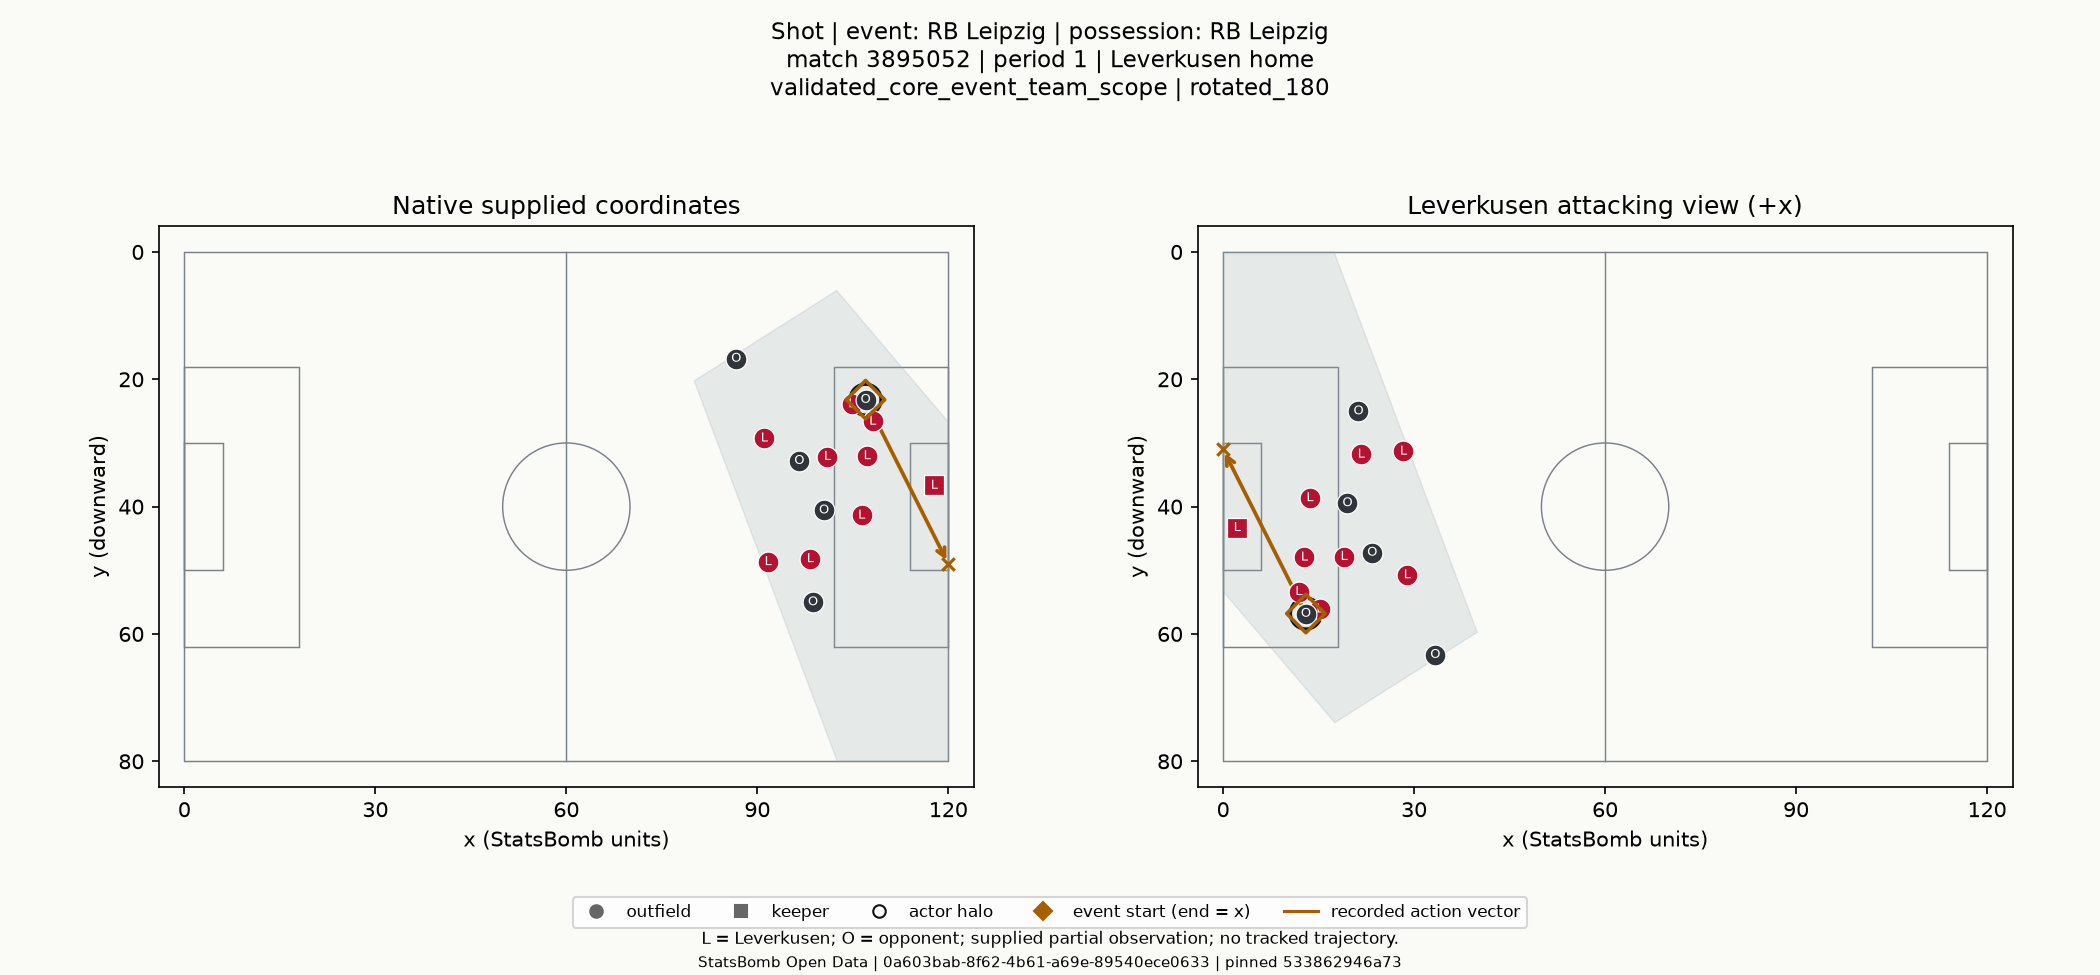

**Pass ? Bayer Leverkusen, period 2**

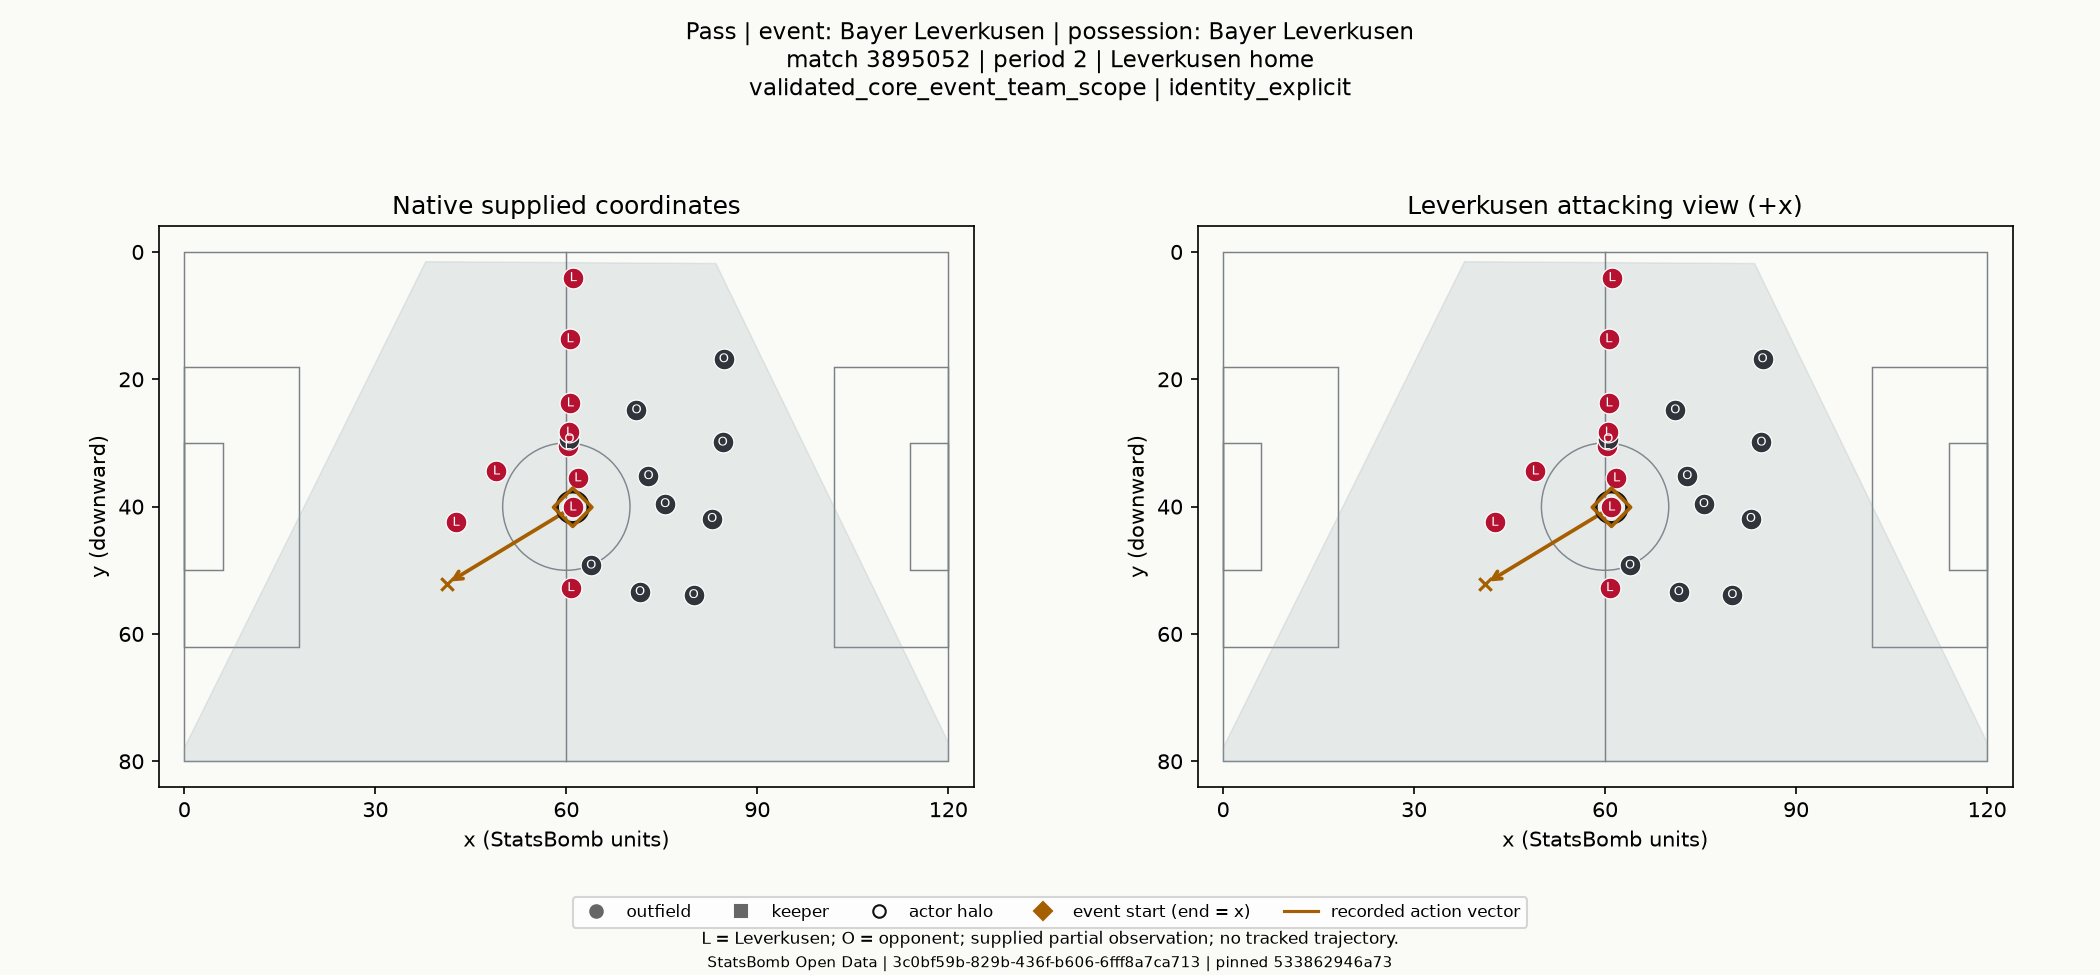

**Pass ? Borussia Mönchengladbach, period 2**

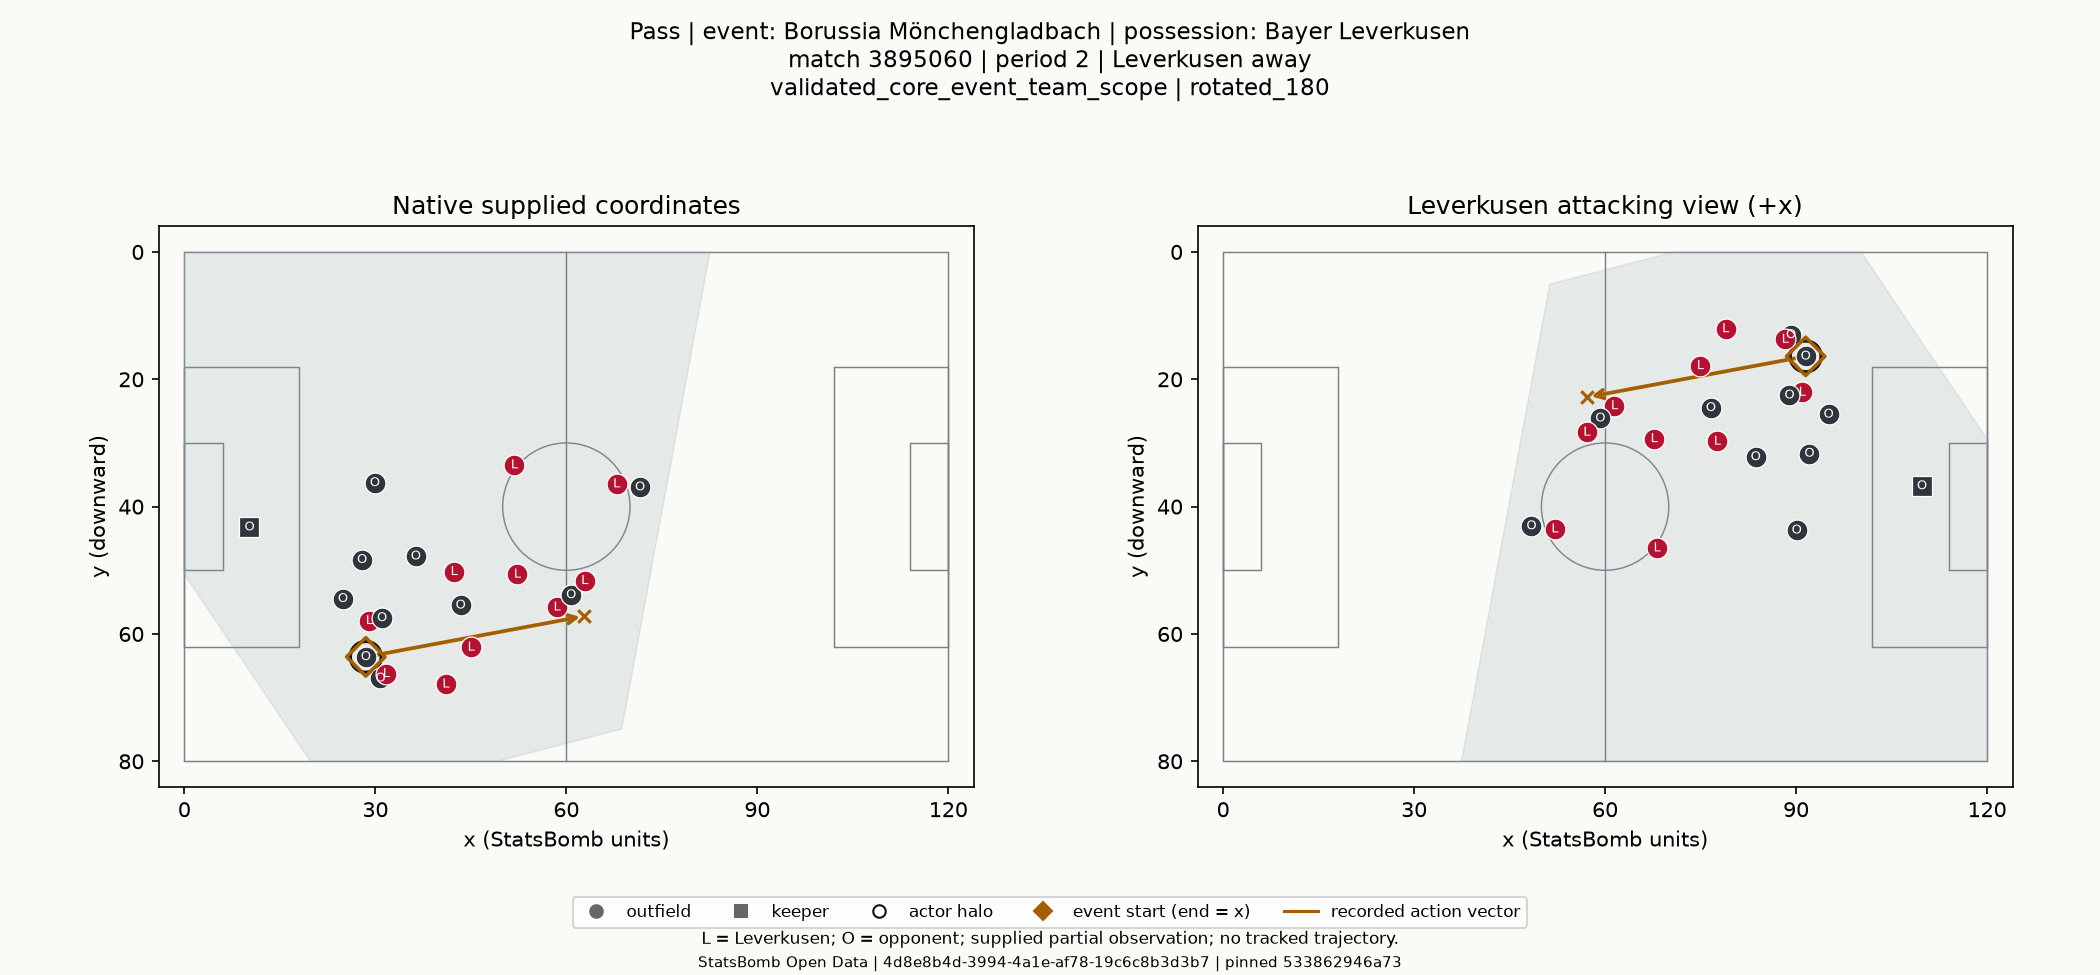

**Dispossessed ? Bayer Leverkusen, period 1**

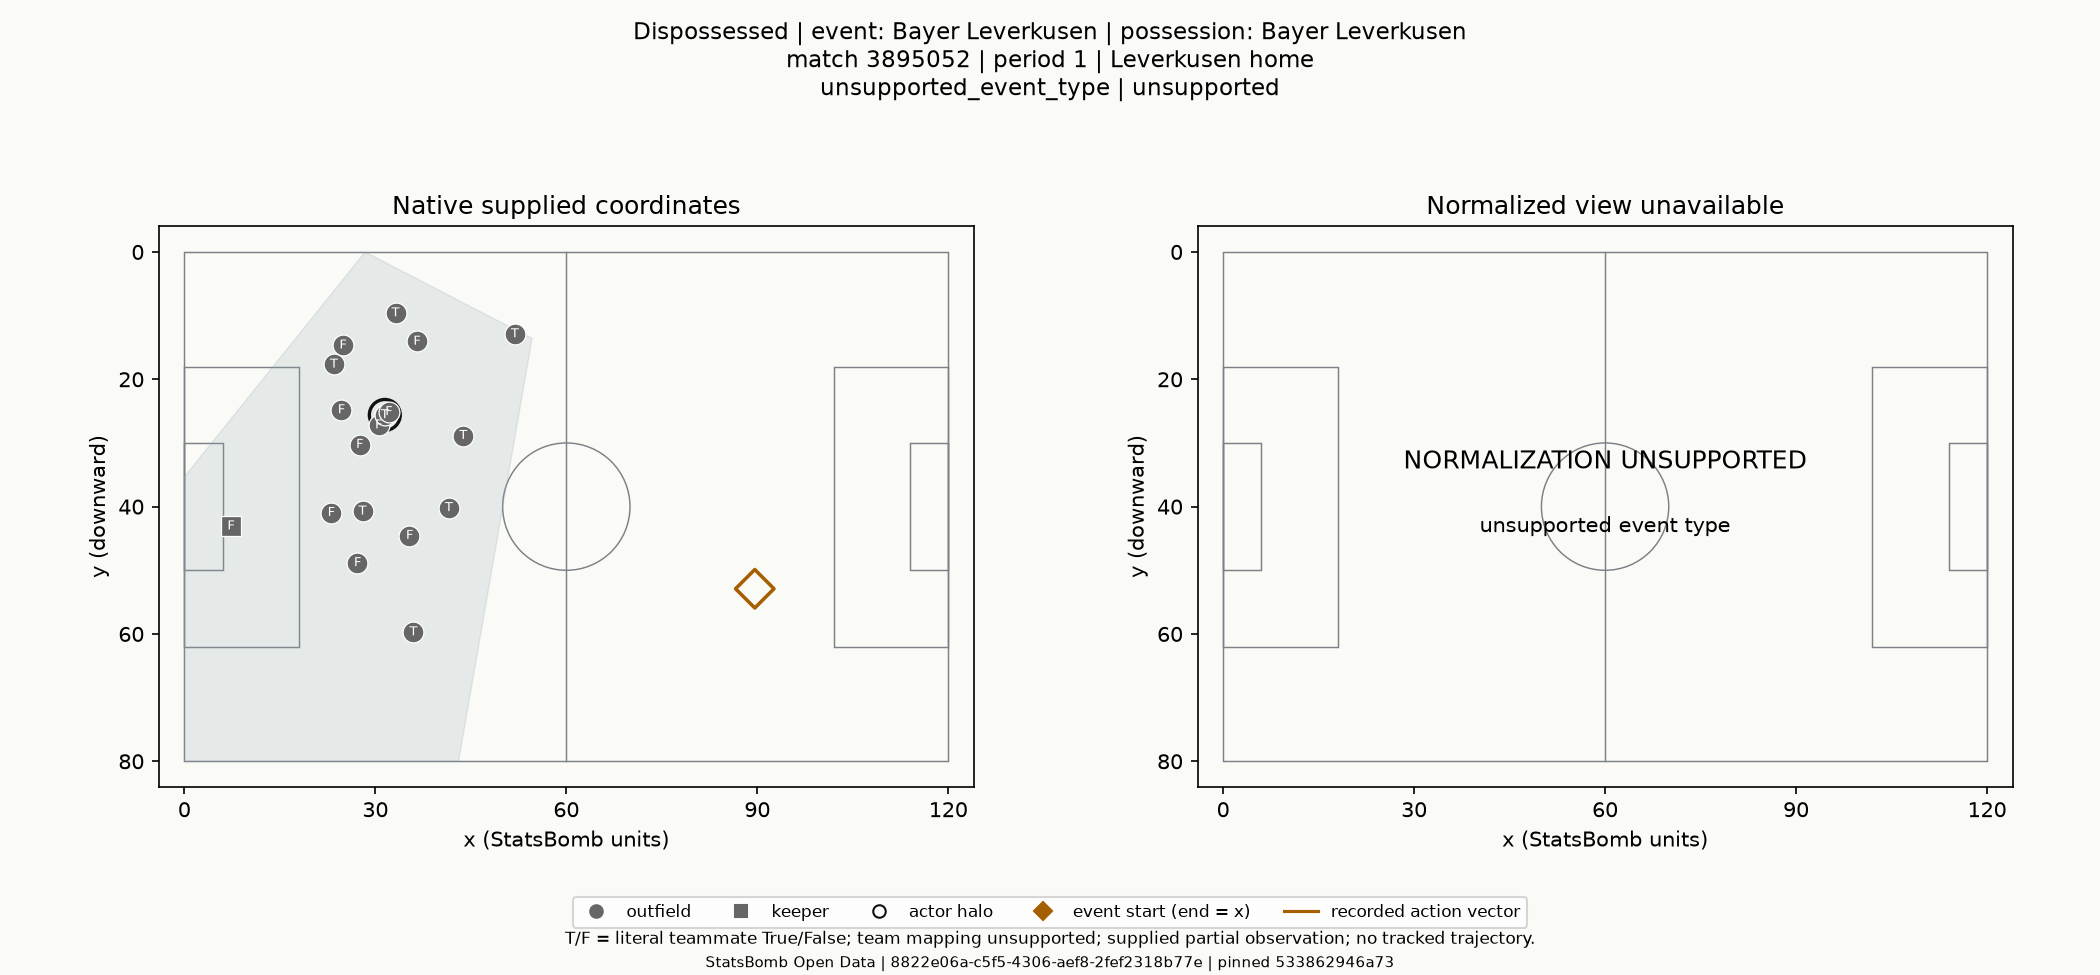

In [8]:
representatives = read('representative_frames')
assert len(representatives) == 27
assert set(representatives.period) == {1, 2}
assert set(representatives.leverkusen_home) == {True, False}
display(representatives[['match_id', 'event_type', 'event_team_name', 'possession_team_name', 'period', 'semantics_status', 'selection_rules', 'figure']])
for index in [0, 6, 8, 17]:
    row = representatives.iloc[index]
    display(Markdown(f"**{row.event_type} ? {row.event_team_name}, period {row.period}**"))
    display(Image(filename=str(ROOT / 'outputs/figures' / row.figure), width=1000))

## 8. Final decision and readiness

**VALIDATED PARTIALLY ? NOT LOCKED.**

- Intended teammate semantics are actor/event-team relative, with observed linked-cloud contradictions.
- C (event versus possession) is resolved for the full pinned sample. B/D/E/G (mapping, orientation, transform and football plotting) are supported only within the conservative 72,596-frame scope.
- A is not a universal observed guarantee; F identifies material unresolved paired and mixed types. Unknown anonymous off-ball identities limit independent verification.
- The full research gate requires provider-backed resolution or a separately justified restricted population. Full-sample reliable sequence construction, tactical interpretation and outcome analysis remain blocked.

The supported mapping is True -> event team, False -> other match team. Leverkusen/opponent labeling reverses accordingly for opponent events. Possession context stays separate. No universal defending-team label or tactical inference is emitted.

## 9. Conditional visualization convention

See the [style guide](../docs/visualization_style_guide.md). Leverkusen red, opponent charcoal, gold action and subdued polygon apply only to validated semantics. L/O text, keeper squares, outfield circles and actor halos make the grammar independent of hue.

A **solid** provider action vector requires explicit start/end coordinates. A **dashed** event-to-event progression indicator is reserved for future observations and has unknown physical path. Neither describes continuous tracking. No sequence arrows are constructed here.

In [9]:
display(pd.DataFrame([
    {'meaning': 'Leverkusen', 'value': style.LEVERKUSEN_COLOR},
    {'meaning': 'Opponent', 'value': style.OPPONENT_COLOR},
    {'meaning': 'Action', 'value': style.ACTION_COLOR},
    {'meaning': 'Visible polygon', 'value': style.POLYGON_COLOR},
    {'meaning': 'Solid arrow', 'value': style.PROVIDER_ACTION_MEANING},
    {'meaning': 'Dashed arrow', 'value': style.EVENT_TRANSITION_MEANING},
]))
assert style.PROVIDER_ACTION_ARROW['linestyle'] != style.EVENT_TRANSITION_ARROW['linestyle']

,meaning,value
0,Leverkusen,#B51232
1,Opponent,#30343B
2,Action,#A65F00
3,Visible polygon,#91A5B0
4,Solid arrow,recorded action vector; explicit provider star...
5,Dashed arrow,event-to-event progression indicator; physical...
